# Modélisation — Prévision du Prix Day-Ahead Français
**EDHEC MSc Data Analysis & AI — Mémoire de Master**

Quatre modèles sont comparés :
- **Modèle A** — Naïf lag-168h : prix(h) = prix(h−168) (même heure semaine précédente)
- **Modèle B** — Random Forest *sans* météo (ablation)
- **Modèle C** — Random Forest *avec* météo (modèle principal)
- **Modèle D** — XGBoost *avec* météo (comparaison)

Tests statistiques : Diebold-Mariano (1995) avec correction Harvey-Leybourne-Newbold (1997).  
Période de test : mai 2024 – avril 2025 (8 640 heures).

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import PROCESSED_DIR, FIGURES_DIR, METRICS_DIR, TEST_MONTHS, RF_PARAMS, XGB_PARAMS
from src.features import build_feature_matrix, WEATHER_FEATURE_COLS
from src.models import train_random_forest, train_xgboost, naive_forecast
from src.evaluate import compute_all, save_metrics, dm_test

sns.set_theme(style='whitegrid', palette='muted')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print('Chargement des données...')
df = pd.read_parquet(PROCESSED_DIR / 'features.parquet')
print(f'{len(df):,} lignes x {df.shape[1]} colonnes')
print(f'Période : {df.index.min()} -> {df.index.max()}')
df.head(3)

Chargement des données...
64,056 lignes x 36 colonnes
Période : 2018-01-08 00:00:00+01:00 -> 2025-04-30 00:00:00+02:00


,load_forecast_mw,gen_gas_mw,gen_hydro_ror_mw,gen_hydro_reservoir_mw,gen_nuclear_mw,gen_solar_mw,gen_wind_onshore_mw,temperature_2m,solar_radiation,precipitation,...,price_da_eur_mwh_lag48h,price_da_eur_mwh_lag168h,price_da_eur_mwh_roll24h_mean,price_da_eur_mwh_roll168h_mean,hdd,cdd,wind_power_proxy,weather_stress_index,nuclear_avail_ratio,price_da_eur_mwh
2018-01-08 00:00:00+01:00,59650.0,2679.0,5738.0,2373.0,52474.0,0.0,5320.0,6.492950,0.0,0.000146,...,29.45,6.74,35.892917,NaN,10.507050,0.0,100.164597,2.262435,0.832921,18.91
2018-01-08 01:00:00+01:00,57050.0,2735.0,5664.0,1675.0,52080.0,0.0,5292.0,6.373566,0.0,0.000145,...,28.55,4.74,35.369167,NaN,10.626434,0.0,98.367882,2.301988,0.826667,15.15
2018-01-08 02:00:00+01:00,56200.0,2738.0,5624.0,1706.0,51896.0,0.0,5104.0,6.263000,0.0,0.000144,...,28.18,3.66,34.861250,NaN,10.737000,0.0,93.005081,2.369813,0.823746,15.11


## 1. Construction des matrices de features (avec / sans météo)

In [2]:
TARGET = 'price_da_eur_mwh'

# Modèle C / D — avec météo
X, y = build_feature_matrix(df, target=TARGET, include_weather=True)
print(f'X_weather    : {X.shape[0]:,} lignes × {X.shape[1]} features')

# Modèle B — sans météo
X_nw, y_nw = build_feature_matrix(df, target=TARGET, include_weather=False)
print(f'X_no_weather : {X_nw.shape[0]:,} lignes × {X_nw.shape[1]} features')

weather_used = [c for c in WEATHER_FEATURE_COLS if c in X.columns]
print(f'\nCols météo présentes : {weather_used}')

X_weather    : 63,888 lignes × 35 features
X_no_weather : 63,888 lignes × 27 features

Cols météo présentes : ['temperature_2m', 'wind_speed_10m', 'solar_radiation', 'precipitation', 'hdd', 'cdd', 'wind_power_proxy', 'weather_stress_index']


## 2. Séparation Train / Test (12 derniers mois = hors-échantillon)

In [3]:
cutoff = len(X) - TEST_MONTHS * 30 * 24
X_train,  X_test  = X.iloc[:cutoff],    X.iloc[cutoff:]
y_train,  y_test  = y.iloc[:cutoff],    y.iloc[cutoff:]

cutoff_b = len(X_nw) - TEST_MONTHS * 30 * 24
X_b_train, X_b_test = X_nw.iloc[:cutoff_b], X_nw.iloc[cutoff_b:]
y_b_train, y_b_test = y_nw.iloc[:cutoff_b], y_nw.iloc[cutoff_b:]

print(f'Train : {len(X_train):,} heures ({y_train.index.min().date()} -> {y_train.index.max().date()})')
print(f'Test  : {len(X_test):,} heures ({y_test.index.min().date()} -> {y_test.index.max().date()})')
print(f'\nFeatures (avec météo)  : {X_train.shape[1]}')
print(f'Features (sans météo)  : {X_b_train.shape[1]}')

Train : 55,248 heures (2018-01-15 -> 2024-05-05)
Test  : 8,640 heures (2024-05-05 -> 2025-04-30)

Features (avec météo)  : 35
Features (sans météo)  : 27


## 3. Entraînement des modèles

In [4]:
# Modèle A — Naïf
print('Modèle A — Naïf (lag-168h)...')
y_pred_naive = naive_forecast(y).loc[y_test.index]

# Modèle B — RF sans météo
print('Modèle B — Random Forest SANS météo...')
rf_b = train_random_forest(X_b_train, y_b_train)
y_pred_rf_b = pd.Series(rf_b.predict(X_b_test), index=y_b_test.index)

# Modèle C — RF avec météo
print('Modèle C — Random Forest AVEC météo...')
rf_c = train_random_forest(X_train, y_train)
y_pred_rf_c = pd.Series(rf_c.predict(X_test), index=y_test.index)

# Modèle D — XGBoost avec météo
print('Modèle D — XGBoost AVEC météo...')
xgb = train_xgboost(X_train, y_train)
y_pred_xgb = pd.Series(xgb.predict(X_test), index=y_test.index)

# Index commun (intersection des non-NaN)
common_idx = y_test.index
for pred in [y_pred_naive, y_pred_rf_b, y_pred_rf_c, y_pred_xgb]:
    common_idx = common_idx.intersection(pred.dropna().index)

y_true    = y_test.loc[common_idx]
naive_p   = y_pred_naive.loc[common_idx]
rf_b_p    = y_pred_rf_b.loc[common_idx]
rf_c_p    = y_pred_rf_c.loc[common_idx]
xgb_p     = y_pred_xgb.loc[common_idx]

print(f'\nIndex commun : {len(common_idx):,} heures')

Modèle A — Naïf (lag-168h)...
Modèle B — Random Forest SANS météo...
Modèle C — Random Forest AVEC météo...
Modèle D — XGBoost AVEC météo...

Index commun : 8,640 heures


## 4. Évaluation — Tableau de bord des métriques

In [5]:
results = {
    'A — Naïf':          compute_all(y_true, naive_p),
    'B — RF sans météo': compute_all(y_true, rf_b_p),
    'C — RF avec météo': compute_all(y_true, rf_c_p),
    'D — XGBoost':       compute_all(y_true, xgb_p),
}

for name, m in results.items():
    save_metrics(m, name.split(' — ')[0].strip())

comp = pd.DataFrame({
    'MAE (€/MWh)':  {k: round(v['mae'],  2) for k, v in results.items()},
    'RMSE (€/MWh)': {k: round(v['rmse'], 2) for k, v in results.items()},
    'sMAPE (%)':    {k: round(v['smape'], 1) for k, v in results.items()},
    'R²':           {k: round(v['r2'],   3) for k, v in results.items()},
    'Hit (%)':      {k: round(v['hit_ratio'], 1) for k, v in results.items()},
})
print(comp.to_string())
comp

                   MAE (€/MWh)  RMSE (€/MWh)  sMAPE (%)     R²  Hit (%)
A — Naïf                 33.09         44.23       70.9  0.160     59.6
B — RF sans météo        16.95         22.88       44.2  0.775     65.5
C — RF avec météo        16.94         22.85       44.2  0.776     65.4
D — XGBoost              19.14         28.18       45.4  0.659     65.8


,MAE (€/MWh),RMSE (€/MWh),sMAPE (%),R²,Hit (%)
A — Naïf,33.09,44.23,70.9,0.160,59.6
B — RF sans météo,16.95,22.88,44.2,0.775,65.5
C — RF avec météo,16.94,22.85,44.2,0.776,65.4
D — XGBoost,19.14,28.18,45.4,0.659,65.8


## 5. Tests de Diebold-Mariano (HLN 1997)

In [6]:
pairs = [
    ('C vs B — météo apporte-t-elle de la valeur ?', rf_c_p, rf_b_p),
    ('C vs A — RF-météo bat-il le naïf ?',           rf_c_p, naive_p),
    ('B vs A — RF sans météo bat-il le naïf ?',      rf_b_p, naive_p),
    ('D vs C — XGBoost vs RF-météo ?',               xgb_p,  rf_c_p),
]

print(f"{'Test':<48} {'DM stat':>9} {'p-value':>9} {'Signif.':>9}")
print('-' * 78)
dm_rows = []
for label, p1, p2 in pairs:
    stat, pval = dm_test(y_true, p1, p2)
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else 'n.s.'))
    print(f'{label:<48} {stat:>9.3f} {pval:>9.4f} {sig:>9}')
    dm_rows.append({'Test': label, 'DM stat': round(stat, 3), 'p-value': round(pval, 4), 'Signif.': sig})

dm_df = pd.DataFrame(dm_rows).set_index('Test')
dm_df

Test                                               DM stat   p-value   Signif.
------------------------------------------------------------------------------
C vs B — météo apporte-t-elle de la valeur ?        -0.565    0.5721      n.s.
C vs A — RF-météo bat-il le naïf ?                 -53.531    0.0000       ***
B vs A — RF sans météo bat-il le naïf ?            -53.438    0.0000       ***
D vs C — XGBoost vs RF-météo ?                      10.879    0.0000       ***


,DM stat,p-value,Signif.
Test,,,
C vs B — météo apporte-t-elle de la valeur ?,-0.565,0.5721,n.s.
C vs A — RF-météo bat-il le naïf ?,-53.531,0.0000,***
B vs A — RF sans météo bat-il le naïf ?,-53.438,0.0000,***
D vs C — XGBoost vs RF-météo ?,10.879,0.0000,***


## 6. Graphique — Prévision vs Réel (Modèle C, premier mois)

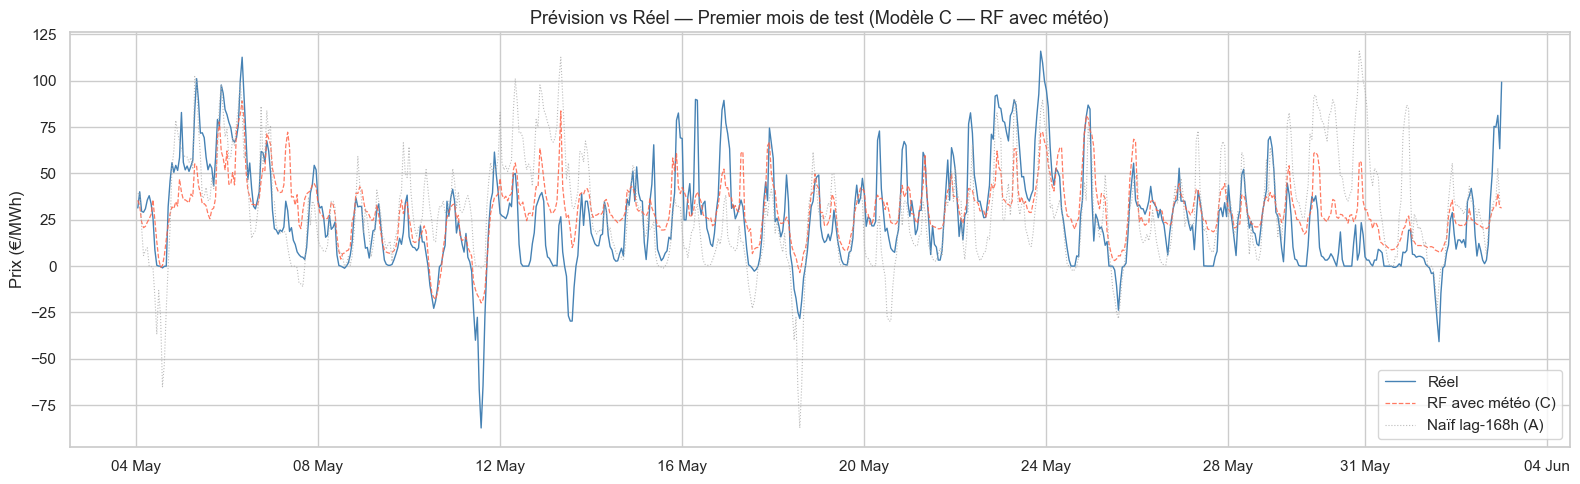

In [7]:
sample_idx = y_true.iloc[:24*30].index

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample_idx, y_true.loc[sample_idx].values, label='Réel', color='steelblue', linewidth=1.0)
ax.plot(sample_idx, rf_c_p.loc[sample_idx].values, label='RF avec météo (C)', color='tomato', linewidth=0.9, linestyle='--', alpha=0.85)
ax.plot(sample_idx, naive_p.loc[sample_idx].values, label='Naïf lag-168h (A)', color='#AAAAAA', linewidth=0.8, linestyle=':', alpha=0.8)
ax.set_title('Prévision vs Réel — Premier mois de test (Modèle C — RF avec météo)', fontsize=13)
ax.set_ylabel('Prix (€/MWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'forecast_vs_actual.png', dpi=150)
plt.show()

## 7. Distribution des erreurs

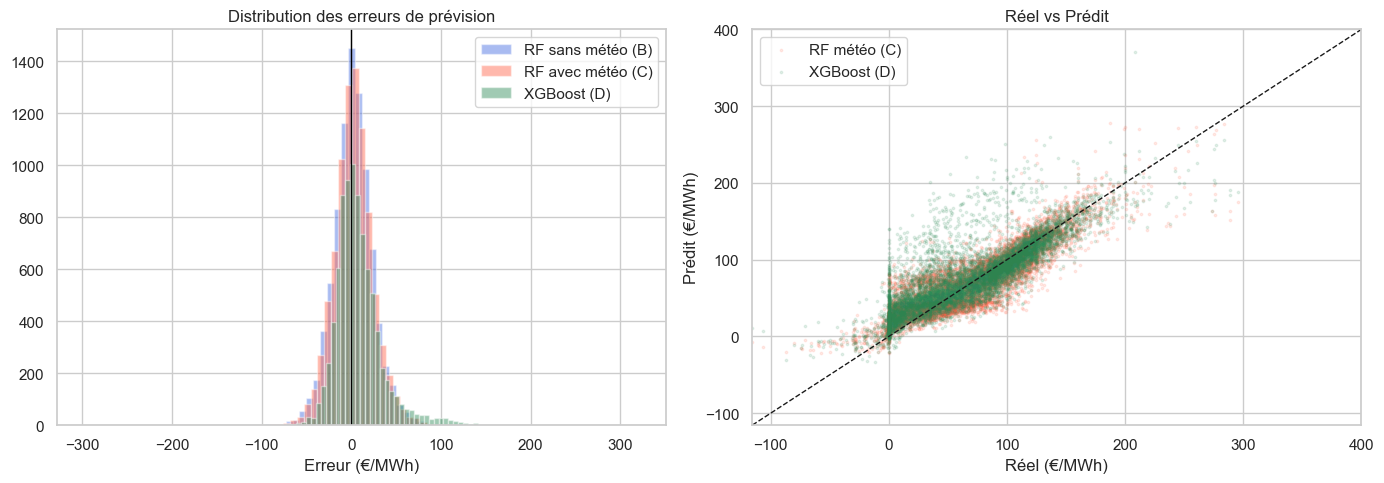

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pred, name, color in [
    (rf_b_p, 'RF sans météo (B)', 'royalblue'),
    (rf_c_p, 'RF avec météo (C)', 'tomato'),
    (xgb_p,  'XGBoost (D)',       'seagreen'),
]:
    err = pred - y_true
    axes[0].hist(err, bins=80, alpha=0.45, label=name, color=color, edgecolor='white')

axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Distribution des erreurs de prévision')
axes[0].set_xlabel('Erreur (€/MWh)')
axes[0].legend()

lims = [y_true.min(), min(y_true.max(), 400)]
axes[1].scatter(y_true, rf_c_p, alpha=0.12, s=3, color='tomato',   label='RF météo (C)')
axes[1].scatter(y_true, xgb_p,  alpha=0.12, s=3, color='seagreen', label='XGBoost (D)')
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_title('Réel vs Prédit')
axes[1].set_xlabel('Réel (€/MWh)'); axes[1].set_ylabel('Prédit (€/MWh)')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'error_distribution.png', dpi=150)
plt.show()

## 8. Importance des variables — Modèle C (Random Forest avec météo)

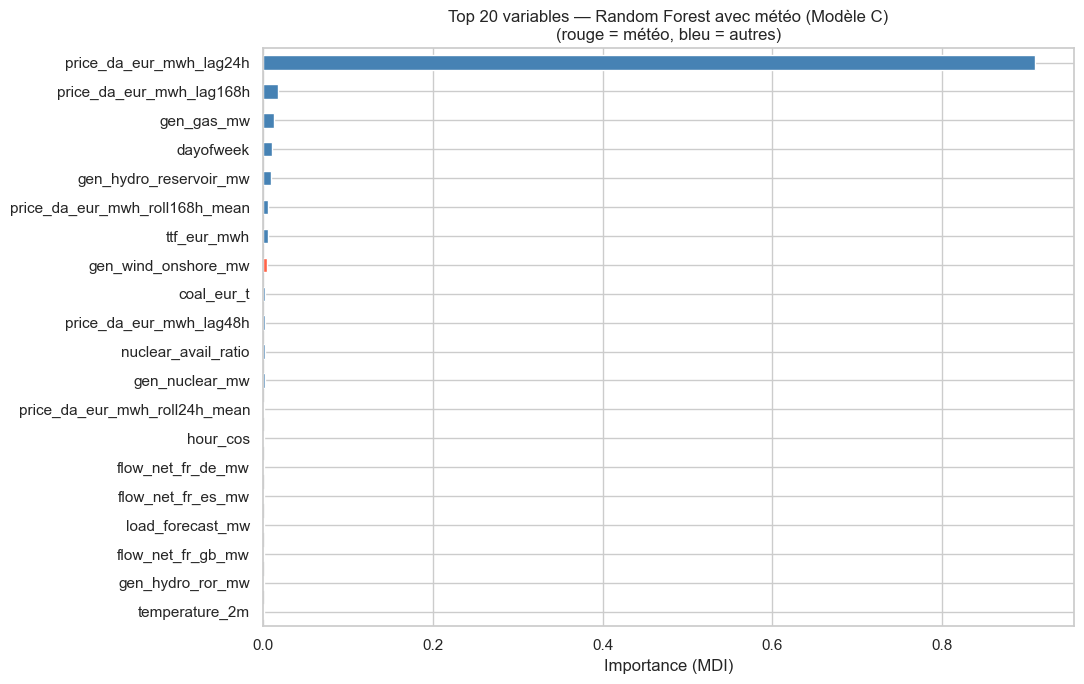


Top 10 features :
price_da_eur_mwh_lag24h           0.9102
price_da_eur_mwh_lag168h          0.0176
gen_gas_mw                        0.0122
dayofweek                         0.0106
gen_hydro_reservoir_mw            0.0090
price_da_eur_mwh_roll168h_mean    0.0058
ttf_eur_mwh                       0.0053
gen_wind_onshore_mw               0.0049
coal_eur_t                        0.0027
price_da_eur_mwh_lag48h           0.0023


In [9]:
importances = pd.Series(rf_c.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

weather_kw = {'temp', 'wind', 'hdd', 'cdd', 'solar', 'precip', 'weather', 'radiation'}
colors = ['tomato' if any(kw in c for kw in weather_kw) else 'steelblue' for c in top20.index]

fig, ax = plt.subplots(figsize=(11, 7))
top20.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 variables — Random Forest avec météo (Modèle C)\n(rouge = météo, bleu = autres)', fontsize=12)
ax.set_xlabel('Importance (MDI)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance_rf.png', dpi=150)
plt.show()

print('\nTop 10 features :')
print(importances.nlargest(10).round(4).to_string())

## 9. MAE mensuelle sur la période de test

MAE mensuelle (période de test) :
          Naïf  RF sans météo  RF avec météo  XGBoost
Mois                                                 
2024-05  21.27          14.42          14.44    12.69
2024-06  27.67          17.22          17.26    17.59
2024-07  24.24          15.83          15.88    15.26
2024-08  34.58          18.63          18.63    17.89
2024-09  26.88          14.69          14.69    13.25
2024-10  29.18          17.27          17.29    15.36
2024-11  23.15          12.53          12.49    10.77
2024-12  51.47          19.23          19.20    14.94
2025-01  53.30          22.95          22.83    18.72
2025-02  39.74          12.50          12.53    10.02
2025-03  36.57          19.03          19.00    15.85
2025-04  27.09          18.20          18.18    68.15


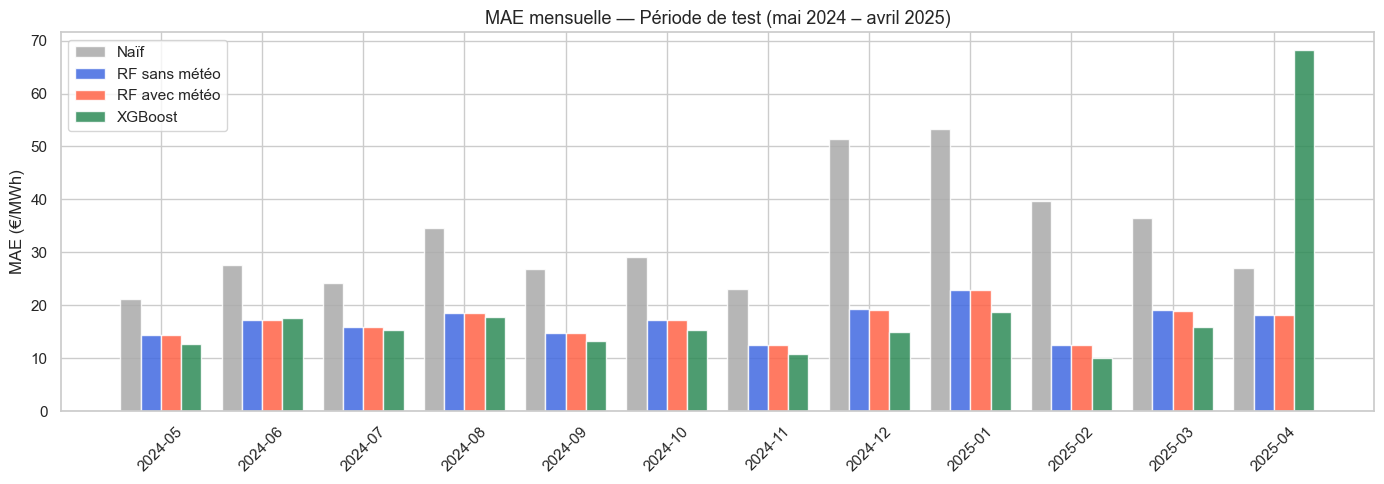

In [10]:
monthly_mae = []
for month, grp in y_true.groupby(y_true.index.to_period('M')):
    idx = grp.index
    monthly_mae.append({
        'Mois':        str(month),
        'Naïf':        np.mean(np.abs(naive_p.loc[idx] - grp)),
        'RF sans météo': np.mean(np.abs(rf_b_p.loc[idx] - grp)),
        'RF avec météo': np.mean(np.abs(rf_c_p.loc[idx] - grp)),
        'XGBoost':     np.mean(np.abs(xgb_p.loc[idx]   - grp)),
    })

monthly_df = pd.DataFrame(monthly_mae).set_index('Mois')
print('MAE mensuelle (période de test) :')
print(monthly_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(monthly_df))
w = 0.2
palette = ['#AAAAAA', 'royalblue', 'tomato', 'seagreen']
for i, (col, color) in enumerate(zip(monthly_df.columns, palette)):
    ax.bar(x + (i - 1.5) * w, monthly_df[col], width=w, label=col, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(monthly_df.index, rotation=45)
ax.set_title('MAE mensuelle — Période de test (mai 2024 – avril 2025)', fontsize=13)
ax.set_ylabel('MAE (€/MWh)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'backtest_mae_by_month.png', dpi=150)
plt.show()

## 10. Comparaison globale — Graphique multi-métriques

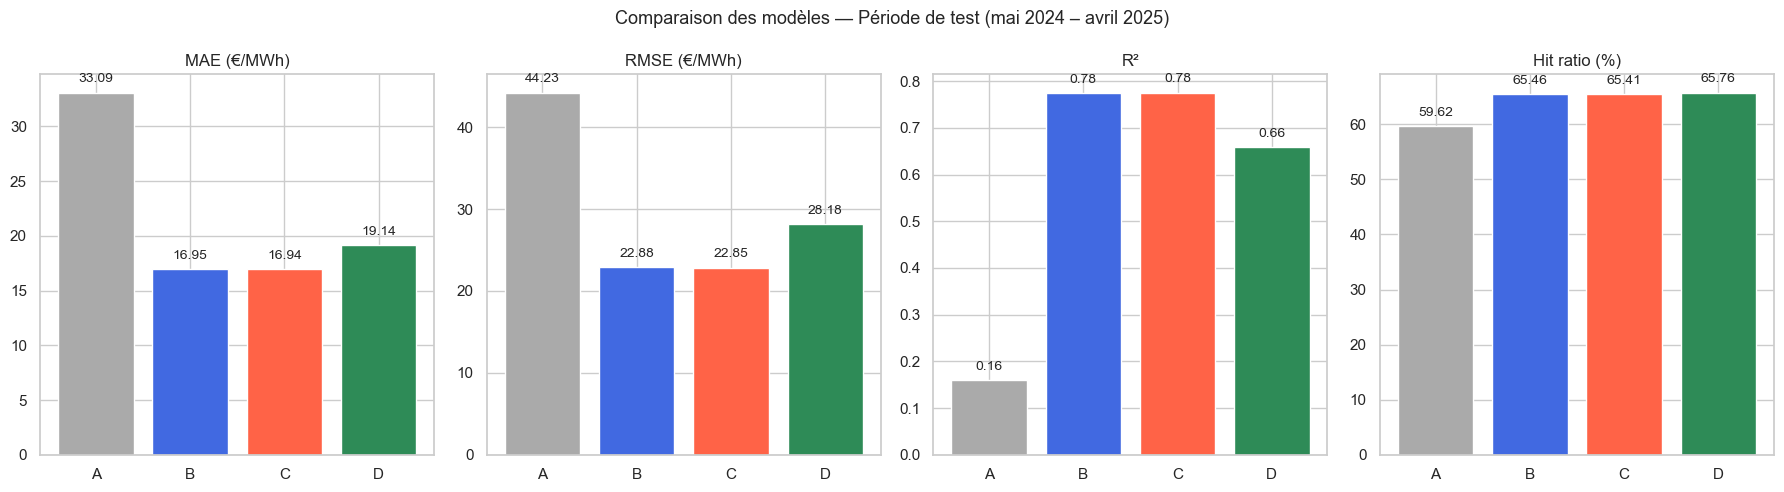


Resultats finaux :
                   MAE (€/MWh)  RMSE (€/MWh)  sMAPE (%)     R²  Hit (%)
A — Naïf                 33.09         44.23       70.9  0.160     59.6
B — RF sans météo        16.95         22.88       44.2  0.775     65.5
C — RF avec météo        16.94         22.85       44.2  0.776     65.4
D — XGBoost              19.14         28.18       45.4  0.659     65.8


In [11]:
model_labels = ['A — Naïf', 'B — RF sans météo', 'C — RF avec météo', 'D — XGBoost']
palette_bar  = ['#AAAAAA', 'royalblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, label in [
    (axes[0], 'mae',       'MAE (€/MWh)'),
    (axes[1], 'rmse',      'RMSE (€/MWh)'),
    (axes[2], 'r2',        'R²'),
    (axes[3], 'hit_ratio', 'Hit ratio (%)'),
]:
    vals = [results[k][metric] for k in results]
    bars = ax.bar(range(4), vals, color=palette_bar)
    ax.set_title(label)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['A', 'B', 'C', 'D'])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Comparaison des modèles — Période de test (mai 2024 – avril 2025)', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResultats finaux :')
print(comp.to_string())